# Research Questions (1.1)

## What type of delays are occuring most at the top 20 airports?
This research questions analyses the airport traffic, airport IATA delays and airport punctuality to understand the delay behaviour at the top 20 airports.


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display


In [77]:
df_AT = pd.read_excel("datasets/AirportTraffic.xlsx")
df_AAD = pd.read_excel("datasets/AA_ATFM_Delay.xlsx")
df_AP = pd.read_excel("datasets/Airports_Punctuality.xlsx")
df_AID= pd.read_excel("datasets/Airport_IATA_delays_airline_reported.xlsx")
df_PDD = pd.read_excel("datasets/Primary_departure_Delay_Causes_AP.xlsx")

## Airport Traffic Analysis
We identified the top 20 airports based on the total number of flights they handled in both 2023 and 2024. The table below presents these airports along with their respective ICAO codes. These codes will also be used in subsequent visualizations to provide airport-specific insights.

In [78]:
df_top20 = (
    df_AT.groupby("APT_ICAO")[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]] #Group by airport code
    .sum().sort_values(by="FLT_TOT_1",ascending=False) #Sum the values for each code of the 3 columns indicated
    .head(20).reset_index()) #Change "20" to change the number of airports analysed
# Adding airport's city name and state from original dataset
df_top20 = (df_top20.merge(df_AT[["APT_ICAO", "APT_NAME", "STATE_NAME"]]
                           .drop_duplicates(), on="APT_ICAO", how="left"))
df_top20.head(20)


airports_code_list = df_top20["APT_ICAO"].unique().tolist()
display(df_top20)

,APT_ICAO,FLT_TOT_1,FLT_DEP_1,FLT_ARR_1,APT_NAME,STATE_NAME
0,LTFM,1014869,507380,507489,Istanbul,Türkiye
1,EHAM,947254,473657,473597,Amsterdam - Schiphol,Netherlands
2,EGLL,933098,466473,466625,London - Heathrow,United Kingdom
3,LFPG,921916,460997,460919,Paris-Charles-de-Gaulle,France
4,EDDF,871219,435565,435654,Frankfurt,Germany
5,LEMD,809535,404744,404791,Madrid - Barajas,Spain
6,LEBL,666969,333465,333504,Barcelona,Spain
7,EDDM,624316,312141,312175,Munich,Germany
8,LIRF,582158,291068,291090,Rome - Fiumicino,Italy
9,EGKK,522331,261146,261185,London - Gatwick,United Kingdom


For the geographical graph in research question 4, the mean airport traffic for every month is summarized and saved as csv file

In [79]:
df_AT_top20 = df_AT[df_AT["APT_ICAO"].isin(df_top20["APT_ICAO"])]

# Calculating the mean for every month
df_AT_top20_month = df_AT_top20.groupby(["APT_ICAO", "YEAR", "MONTH_NUM"])[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]].mean().reset_index()
df_AT_top20_month = df_AT_top20_month.rename(columns={
    "FLT_TOT_1": "FLT_MEAN",
    "FLT_DEP_1": "FLT_MEAN_DEP",
    "FLT_ARR_1": "FLT_MEAN_ARR"
})
df_AT_top20_month.to_csv("datasets_rq4/df_AT_top20_month.csv")


## Primary Delay Causes
We start high-level where we provide insights into the major delay categories in general for all top 20 airports. The primary categories analysed include weather government, en_route and airline where the following pie chart provides insights into the distribution of the delay causes for both 2023 and 2024.


In [80]:
df_PDD_TOP20 = (
    df_PDD[df_PDD["APT_ICAO"].isin(airports_code_list)]
)

df_PDD_summary = (
    df_PDD_TOP20
    .groupby(["Year","APT_ICAO"], as_index=False)
    .agg({
        "Airline": "sum",
        "En_Route": "sum",
        "Miscellaneous": "sum",
        "Government": "sum",
        "Weather": "sum",
        
    })
    .sort_values(by="APT_ICAO", ascending=False)   
    .reset_index(drop=True)
)
display(df_PDD_summary)

,Year,APT_ICAO,Airline,En_Route,Miscellaneous,Government,Weather
0,2024,LTFM,1245907,319605,14731,39107,80434
1,2023,LTFM,1159965,159492,35401,68650,158099
2,2023,LTFJ,125119,18530,1544,2689,29190
3,2024,LTFJ,142016,26289,1477,1200,15095
4,2023,LTAI,126589,120799,14929,6321,14530
5,2024,LTAI,132903,208398,22782,7086,19912
6,2023,LSZH,321470,124558,26433,51344,66226
7,2024,LSZH,385891,178243,28220,56163,84275
8,2024,LPPT,426979,230703,61130,22005,63660
9,2023,LPPT,511888,222664,56344,22839,34478


C:\Users\vermeej\AppData\Local\Temp\ipykernel_27716\2086170770.py:9: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



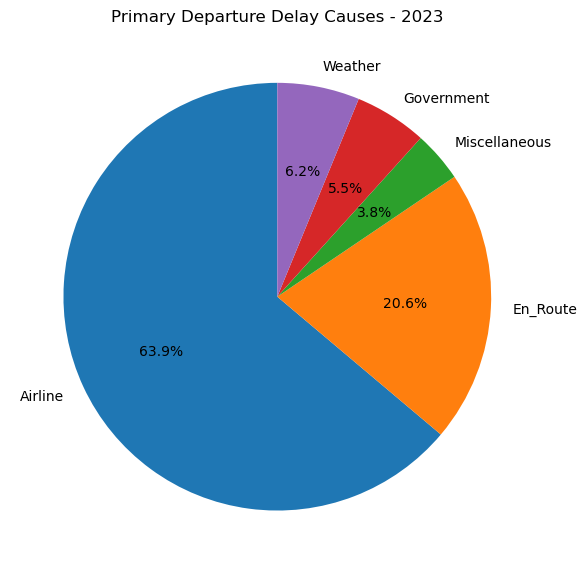

C:\Users\vermeej\AppData\Local\Temp\ipykernel_27716\2086170770.py:9: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



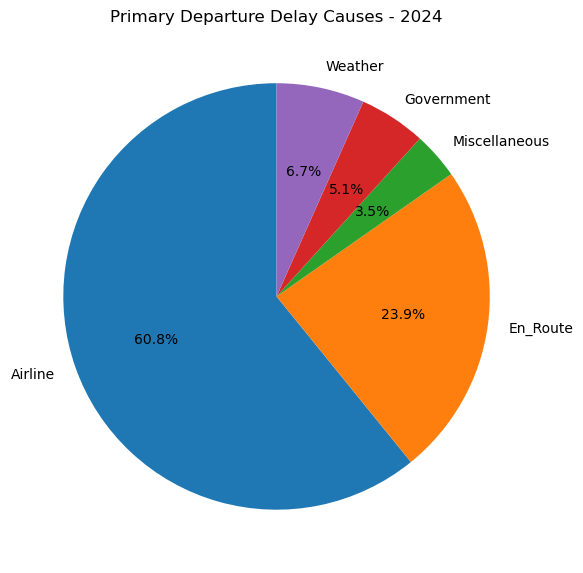

In [81]:
# Delay cause columns
causes = ["Airline", "En_Route", "Miscellaneous", "Government", "Weather"]

# Pie charts for each year
for yr in ["2023", "2024"]:
    data = (
        df_PDD_summary[df_PDD_summary["Year"].astype(str) == yr][causes]
        .sum()
        .fillna(0)
    )

    plt.figure(figsize=(6, 6))
    plt.pie(data.values, labels=causes, autopct="%1.1f%%", startangle=90)
    plt.title(f"Primary Departure Delay Causes - {yr}")
    plt.tight_layout()
    plt.show()


## Airport IATA delays
In the aviation industry, the International Air Transport Association (IATA) has standardized a set of delay categories that enable consistent reporting and benchmarking across airports. Eurocontrol provides these delay reasons for all major European airports, allowing structured comparison of how different operational and external factors contribute to total delay. The data set containts the following important parameters:

- Year lobt = Year of the Last Off-Block Time (LOBT) \
- TD = Total Delay (minutes) \
- TF = Total Flights affected \
- Total Flights Period = total number of flights in that airport/period \
- ADM = Average Delay per Movement = TD/Total Flight Period  (minutes per total flight)
- Total Delay Period = Total delay minutes (all causes) for the period \
- PD = Proportion of delay = (TD / Total Delay Period)*100
- Delay rate = TF / Total flight period

In [82]:
# Filter the delay dataset for only the top 20 airports
df_AID_TOP20 = df_AID[df_AID["APT_ICAO"].isin(airports_code_list)].copy()

# Calculate delay ratio as percentage
df_AID_TOP20["Delay_Ratio"] = (df_AID_TOP20["TF"] / df_AID_TOP20["Total_Flights_Period"]) * 100

# Provide key insights per year per month per airport
df_AID_TOP20_YMA = (
    df_AID_TOP20
    .groupby(["Year_Lobt","Month_Lobt","APT_ICAO","Total_Flights_Period"], as_index=False)
    .agg({
        "TD": "sum",
        "TF": "sum",
        "adm": "sum",
        "pd": "mean",
        "Delay_Ratio": "mean" 
    })
    .sort_values(by="TF", ascending=False)
    .rename(columns={
        "TD": "Total Delay (TD)",
        "TF": "Total Flights (TF)",
        "adm": "Avg Delay per Movement (in min)",
        "pd": "Avg Proportion of Delay (%)",
        "Delay_Rate": "Avg Delay Ratio (%)"
    })
    .reset_index(drop=True)
)

df_AID_TOP20_YMA.to_csv("datasets_rq4/df_AID_TOP20_YMA.csv")
display(df_AID_TOP20_YMA)


,Year_Lobt,Month_Lobt,APT_ICAO,Total_Flights_Period,Total Delay (TD),Total Flights (TF),Avg Delay per Movement (in min),Avg Proportion of Delay (%),Delay_Ratio
0,2024,July,EDDF,14380,295785,25288,20.569193,4.243149,10.344433
1,2024,August,EDDF,14361,242797,23770,16.906692,4.492451,9.736337
2,2024,September,EDDF,14179,213238,23435,15.039001,4.513545,9.722332
3,2023,August,EDDF,14135,291567,21990,20.627308,4.496111,9.151252
4,2023,July,EDDF,13967,246893,21909,17.676881,4.288736,9.227212
...,...,...,...,...,...,...,...,...,...
474,2024,March,LTAI,2289,10483,942,4.579729,3.955655,2.420785
475,2023,November,LTAI,939,10645,865,11.336528,2.820361,5.418781
476,2024,February,LTAI,1673,8567,826,5.120741,4.072252,2.904258
477,2024,April,LTFJ,218,5679,128,26.050459,5.540866,3.453859


**Delay trend analysis**  
The following figure provides insights into the delay ratio per month for the airports comparing 2023 and 2024. It also contains a dropdown bar to select specific airport codes to understand airport specific delay ratios. 

In [83]:
df_AID_TOP20_YMA = df_AID_TOP20_YMA.rename(columns={
    "Delay_Ratio": "Avg Delay Ratio (%)"
})

# month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Aggregate dataframe for line chart
df_avg = (
    df_AID_TOP20_YMA
    .groupby(["Year_Lobt", "Month_Lobt", "APT_ICAO"], as_index=False)[["Avg Delay Ratio (%)"]]
    .mean()
)

# Month lobt follows chronological order
df_avg["Month_Lobt"] = pd.Categorical(df_avg["Month_Lobt"], categories=month_order, ordered=True)

# all_airport order
df_all_avg = (
    df_avg.groupby(["Year_Lobt", "Month_Lobt"], as_index=False)[["Avg Delay Ratio (%)"]]
    .mean()
)
df_all_avg["APT_ICAO"] = "ALL"

# Combine & sort
df_plot = pd.concat([df_avg, df_all_avg], ignore_index=True)
df_plot = df_plot.sort_values(["APT_ICAO", "Year_Lobt", "Month_Lobt"])

# Plot function with airport filter
def plot_delay_ratio(selected_airport="ALL"):
    if selected_airport == "ALL":
        dff = df_plot[df_plot["APT_ICAO"] == "ALL"]
        title = "Average Delay Ratio by Month — All Airports"
    else:
        dff = df_plot[df_plot["APT_ICAO"] == selected_airport]
        title = f"Average Delay Ratio by Month — {selected_airport}"
    
    # Plot one line per year
    fig = px.line(
        dff,
        x="Month_Lobt",
        y="Avg Delay Ratio (%)",
        color="Year_Lobt",
        markers=True,
        line_shape="linear", 
        title=title,
        labels={
            "Month_Lobt": "Month",
            "Avg Delay Ratio (%)": "Average Delay Ratio (%)",
            "Year_Lobt": "Year"
        }
    )

    fig.update_layout(
        template="plotly_white",
        xaxis=dict(categoryorder="array", categoryarray=month_order),
        yaxis_title="Average Delay Ratio (%)",
        hovermode="x unified",
        xaxis_tickangle=-45,
        legend_title="Year"
    )

    fig.show()

# Dropdown for airport selection
airport_list = ["ALL"] + sorted(df_AID_TOP20_YMA["APT_ICAO"].unique())

dropdown = widgets.Dropdown(
    options=airport_list,
    value="ALL",
    description="Airport:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='40%')
)

widgets.interact(plot_delay_ratio, selected_airport=dropdown)

C:\Users\vermeej\AppData\Local\Temp\ipykernel_27716\759221278.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



interactive(children=(Dropdown(description='Airport:', layout=Layout(width='40%'), options=('ALL', 'EDDF', 'ED…

<function __main__.plot_delay_ratio(selected_airport='ALL')>

When analyzing the trendline, we can conclude that there is a seasonal delay peak happening in the summer. The average delay ratio climbs from 3.5% in winter to 5.5% in summer. When comparing 2023 with 2024, we can see some differences but overall we see a consistent trend.

**Delay reason heatmap**  
The delay heatmap below presents the distribution of IATA delay reasons across the top 20 European airports, showing how each airport’s total delay minutes are divided among standardized categories. Darker shades represent a higher share of a particular delay reason at that airport.


In [84]:
# Filter the delay dataset for only the top 20 airports
df_AID_TOP20 = df_AID[df_AID["APT_ICAO"].isin(airports_code_list)].copy()

# Aggregate airport + label 
df_delay_types = (
    df_AID_TOP20
    .groupby(["APT_ICAO", "Label"], as_index=False)["TD"]
    .sum()
)

# Delay heatmap
pivot = (
    df_delay_types
    .pivot_table(index="Label", columns="APT_ICAO", values="TD", aggfunc="sum", fill_value=0)
)

pivot_share = pivot.div(pivot.sum(axis=0), axis=1)

fig = px.imshow(
    pivot_share,
    aspect="auto",
    color_continuous_scale="Blues",
    title="IATA Delay heatmap per airport",
    labels=dict(x="Airport (ICAO)", y="IATA Delay Reason", color="Share of delay")
)

fig.data[0].update(
    xgap=1, ygap=1
)

fig.update_layout(
    height=750,
    width=1100,
    margin=dict(l=200, r=50, t=80, b=80)  

)

fig.update_layout(height=700, width=1000)
fig.show()

This visualization highlights that “Aircraft and Ramp Handling” and “ATFM En-Route Demand/Capacity” are the most prominent delay sources across the network.

# Airport Punctionality
The airport arrival and departure punctuality are also analyzed for the airports to understand if it happens upon arrival or departure. The figure below compares average departure and arrival punctuality across airports. Each bar represents the proportion of flights departing or arriving on time, based on Eurocontrol’s performance data.

In [85]:
airport_map = {
    "LTFM": "Istanbul",
    "EHAM": "Amsterdam",
    "EGLL": "London Heathrow",
    "LFPG": "Paris Charles de Gaulle",
    "EDDF": "Frankfurt",
    "LEMD": "Madrid Barajas",
    "LEBL": "Barcelona",
    "EDDM": "Munich",
    "LIRF": "Rome Fiumicino",
    "EGKK": "London Gatwick",
    "LSZH": "Zurich",
    "LGAV": "Athens",
    "EIDW": "Dublin",
    "LOWW": "Vienna",
    "LEPA": "Palma de Mallorca",
    "EKCH": "Copenhagen",
    "LPPT": "Lisbon",
    "LTFJ": "Istanbul Sabiha Gokcen",
    "LTAI": "Antalya",
    "ENGM": "Oslo"
}

top20_codes = [airport_map[a] for a in df_top20['APT_ICAO'] if a in airport_map]
df_AP_top20 = df_AP[df_AP['Airport'].isin(top20_codes)]

name_to_icao = {name: icao for icao, name in airport_map.items()}
icao_codes = df_AP_top20["Airport"].map(name_to_icao)
df_AP_top20.insert(loc=2, column="APT_ICAO", value=df_AP_top20["Airport"].map(name_to_icao))

df_AP_top20

,Date,Airport,APT_ICAO,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
1367,2022-01-01,Frankfurt,EDDF,0.818898,0.804217,13.043920,13.426908,-0.382988,0.922170
1368,2022-01-02,Frankfurt,EDDF,0.707216,0.713389,17.652062,18.506590,-0.854528,0.946463
1369,2022-01-03,Frankfurt,EDDF,0.738938,0.755991,16.235140,13.956209,2.278931,0.952183
1370,2022-01-04,Frankfurt,EDDF,0.630542,0.725962,16.605624,14.621955,1.983669,0.953811
1371,2022-01-05,Frankfurt,EDDF,0.782816,0.821951,10.382379,9.699187,0.683192,0.946785
...,...,...,...,...,...,...,...,...,...
43735,2025-09-24,Istanbul,LTFM,0.840440,0.831309,8.972031,11.150967,-2.178936,0.922894
43736,2025-09-25,Istanbul,LTFM,0.794157,0.843750,11.858544,8.783967,3.074576,0.930314
43737,2025-09-26,Istanbul,LTFM,0.713147,0.770039,15.778220,13.545795,2.232425,0.938824
43738,2025-09-27,Istanbul,LTFM,0.748021,0.782377,17.316623,13.748999,3.567624,0.948931


In [86]:
# Compute average punctuality per airport
df_avg = df_AP_top20.groupby('Airport', as_index=False)[
    ['Departure Punctuality %', 'Arrival Punctuality %']
].mean()

# convert to percentage
df_avg['Departure Punctuality %'] *= 100
df_avg['Arrival Punctuality %'] *= 100

# Melt dataframe
df_melt = df_avg.melt(id_vars='Airport', 
                      value_vars=['Departure Punctuality %', 'Arrival Punctuality %'],
                      var_name='Type', value_name='Punctuality (%)')

# punctuality bar chart
fig = px.bar(
    df_melt,
    x='Airport',
    y='Punctuality (%)',
    color='Type',
    barmode='group',
    title='Average Departure vs Arrival Punctuality by Airport',
)

fig.update_layout(
    xaxis_title='Airport',
    yaxis_title='Punctuality (%)',
    xaxis_tickangle=45,
    template='plotly_white',
    height=600
)

fig.show()

Overall, the chart shows that arrival punctuality is consistently higher than departure punctuality, suggesting that airlines often recover part of the delay during flight operations. Airports such as Munich, Oslo, and Zurich achieve the highest punctuality rates (around 75–80%), while Lisbon, Istanbul, and Palma de Mallorca exhibit lower departure performance, likely due to congestion and ground-handling constraints.